In [28]:
import time

import numpy as np
import pandas as pd
from bitalg.tests.test2 import Test
import matplotlib.pyplot as plt
import matplotlib
from bitalg.visualizer.main import Visualizer

In [29]:
def generate_uniform_points(left=-100, right=100, n=100):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym
    obszarze od left do right (jednakowo na osi y)
    o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
             np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    result = [None for _ in range(n)]
    for i in range(n):
        result[i] = (np.random.uniform(left, right), np.random.uniform(left, right))
    return result

In [30]:
def mat_det_2x2(a, b, c):
    """
    Obliczanie wyznacznika macierzy 2x2 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return (a[0]-c[0])*(b[1]-c[1]) - (b[0]-c[0]) * (a[1]-c[1])

In [31]:
def orient(a,b,c):
    r = mat_det_2x2(a,b,c)
    if r >0: return 1 
    elif r<0: return -1
    else: return 0
def bin_r_tangent(p, hull):
    

    n = len(hull)
    if n==1:
        return 0
    if n==2:
        if cmp(p, hull[0], hull[1]) <0:
            return 0
        else: return 1
    #analizujemy wierzhołi od [v0, v1, .., vn]  gdzie vn = v0
    l, r = 0, len(hull)
    # sprawdzamy czy v0 jest wierzchołkiem stycznym
    if orient(p, hull[0], hull[1]) >0 and orient(p, hull[0], hull[n - 1]) >=0:
        return 0
    while True:
        c = (l+r)//2
        # sprawdzamy, czy vc jest wierzchołkiem stycznym
        if orient(p, hull[c], hull[(c + 1) % n]) >0 and orient(p, hull[c], hull[(c - 1) % n]) >=0:
            return c
        # sprawdzamy czy wektor vl v(l+1) jest skierowany "do góry" <=> vl należy do łańcucha rosnącego
        if isEdgeIncreasing(hull, l, n, p):
            # sprawdzamy czy wektor vc v(c+1) jest skierowany "do dołu" <=> vc należy do łańcucha malejącego
            if isEdgeDecreasing(c, hull, n, p):
                # wierzchołek styczny będzie w przedziale [l,c]
                r=c
            # w innym przypadku vl należy vc należy do łańcucha rosnącego
            else:
                if orient(p, hull[l], hull[c]) <0 or (isCollinearAndDecreasingP(c, hull, l, n, p) and d(p, hull[l]) < d(p, hull[(c) % n])) or (isCollinearAndApproachingP(c, hull, l, n, p) and d(p, hull[l]) > d(p, hull[(c) % n])):
                    # wierzchołek styczny będzie w przedziale [c,r]
                    l=c
                else:
                    # wierzchołek styczny będzie w przedziale [l,c]
                    r=c

        else:
            if isEdgeIncreasing(hull, c, n, p):
                l=c
            else:
                if( orient(p, hull[l], hull[c]) <0) or (isCollinearAndDecreasingP(c, hull, l, n, p) and d(p, hull[l]) < d(p, hull[(c) % n])) or (isCollinearAndApproachingP(c, hull, l, n, p) and d(p, hull[l]) > d(p, hull[(c) % n])):
                    r=c
                else:
                    l=c


def isEdgeDecreasing(c, hull, n, p):
    return orient(p, hull[c], hull[(c + 1) % n]) > 0


def isEdgeIncreasing(hull, l, n, p):
    return orient(p, hull[l], hull[(l + 1) % n]) <= 0


def isCollinearAndApproachingP(c, hull, l, n, p):
    return (orient(p, hull[l], hull[(l + 1) % n]) == 0 and d(p, hull[l]) > d(p, hull[(l + 1) % n])) or (
                orient(p, hull[c], hull[(c + 1) % n]) == 0 and d(p, hull[c]) > d(p, hull[(c + 1) % n])) and orient(p, hull[l], hull[c])==0


def isCollinearAndDecreasingP(c, hull, l, n, p):
    return (orient(p, hull[l], hull[(l + 1) % n]) == 0 and d(p, hull[l]) < d(p, hull[(l + 1) % n])) or (
                orient(p, hull[c], hull[(c + 1) % n]) == 0 and d(p, hull[c]) < d(p, hull[(c + 1) % n])) and orient(p, hull[l], hull[c])==0



In [32]:
def bin_r_tangent_OLD(p, hull):

    def orient(a,b,c):
        r = mat_det_2x2(a,b,c)
        if r >0: return 1
        elif r<0: return -1
        else: return 0
    n = len(hull)
    if n==1:
        return 0
    if n==2:
        if cmp(p, hull[0], hull[1]) <0:
            return 0
        else: return 1
    #analizujemy wierzhołi od [v0, v1, .., vn]  gdzie vn = v0
    l, r = 0, len(hull)
    # sprawdzamy czy v0 jest wierzchołkiem stycznym
    if orient(p, hull[0], hull[1]) >0 and orient(p, hull[0], hull[n - 1]) >=0:
        return 0
    while True:
        c = (l+r)//2
        # sprawdzamy, czy vc jest wierzchołkiem stycznym
        if orient(p, hull[c], hull[(c + 1) % n]) >0 and orient(p, hull[c], hull[(c - 1) % n]) >=0:
            return c
        # sprawdzamy czy wektor vl v(l+1) jest skierowany "do góry" <=> vl należy do łańcucha rosnącego
        if orient(p, hull[l], hull[(l + 1) % n]) <=0:
            # sprawdzamy czy wektor vc v(c+1) jest skierowany "do dołu" <=> vc należy do łańcucha malejącego
            if orient(p, hull[c], hull[(c+1)%n]) >0:
                # wierzchołek styczny będzie w przedziale [l,c]
                r=c
            # w innym przypadku vl należy vc należy do łańcucha rosnącego
            else:
                if orient(p, hull[l], hull[c]) <=0:
                    # wierzchołek styczny będzie w przedziale [c,r]
                    l=c
                else:
                    # wierzchołek styczny będzie w przedziale [l,c]
                    r=c

        else:
            if orient(p, hull[c], hull[(c + 1) % n]) <=0:
                l=c
            else:
                if( orient(p, hull[l], hull[c]) <=0):
                    r=c
                else:
                    l=c



In [33]:
from functools import cmp_to_key
def min_y(Q):
    n = len(Q)
    mini = Q[0]
    for i in range(n):
        if Q[i][1] < mini[1] or (Q[i][1] == mini[1] and Q[i][0] < mini[0]):
            mini=Q[i]
    return mini
def d(a, b):
    return (b[0]-a[0])**2+(b[1]-a[1])**2
EPS = 10 **(-24)
def _orient(a,b,c):
    r = mat_det_2x2(a,b,c)
    if abs(r) < EPS:
        return 0
    elif r >0: return 1 
    else: return -1
def compare(p0,p1,p2):
    r = _orient(p0,p1,p2)
    if r==-1:
            return 1
    elif r==1: return -1
    else:
        if d(p0, p2) >= d(p0, p1):
            return -1
        else:
            return 1
        
def rm_duplicates(Q,p0):
    result = [p0]
    n = len(Q)
    i=2
    while i < n:
        while i<n and _orient(p0, Q[i-1], Q[i])==0:
            
            i+=1
        result.append(Q[i-1])
        i+=1
    if len(Q)>1 and i==n: result.append(Q[-1])
    return result
def graham_algorithm(Q):
    '''
    Funkcja buduje otoczkę wypukłą dla podanego
    zbioru punktów Q algorymem Grahama
    :parm Q: zbiór punktów
    :return: tablica punktów w postaci krotek współrzędnych
    '''
    p0=min_y(Q)
    Q.sort(key=cmp_to_key(lambda a, b: compare(p0, a, b)))
    Q= rm_duplicates(Q, p0)
    m=len(Q)
    S=[]
    for i in range(min(m,3)):
        S.append(Q[i])
    for i in range(3,m):
        while len(S)>2 and _orient(S[-2], S[-1], Q[i]) !=1:
            S.pop()
        S.append(Q[i])
    return S

In [34]:
def cmp(p0,p1,p2):
    r = _orient(p0,p1,p2)
    if r==-1:
            return 1
    elif r==1: return -1
    else:
        if d(p0, p2) < d(p0, p1):
            return -1
        else:
            return 1
def Partial_Hull(P, m):
    hulls = [graham_algorithm(P[i:i + m]) for i in range(0, len(P), m)]
    r = len(hulls)
    hull = [(float('-inf'),0),min_y(P)]
    for k in range(0,m):
        x = bin_r_tangent(hull[-1], hulls[0])
        q_max = hulls[0][x]
        for i in range(1,r):
            x = bin_r_tangent(hull[-1], hulls[i])
            q_i = hulls[i][x]
            if cmp(hull[-1], q_i,q_max) <0:
                q_max = q_i
        if q_max == hull[1]:
            return hull
        hull.append(q_max)
        
def Convex_Hull(P):
    if len(P) <=2:
        return P
    n = len(P)
    t=1
    while True:
        m = min(n, 2**(2**t))
        hull = Partial_Hull(P, m)
        if hull is not None:
            return hull[1:]
        t+=1


In [35]:
Test().runtest(1, Convex_Hull)

Lab 2, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 5.105s


In [36]:
def display_convex_hull(v,points,hull):
    v.clear()
    v.add_point(points)
    v.add_point(hull,color="red")
    v.add_line_segment([(hull[i], hull[i+1]) for i in range(len(hull)-1)],color="red")
    v.add_line_segment([hull[-1], hull[0]],color="red")
    v.show()

In [88]:
import matplotlib.pyplot
def Partial_Hull_vis(P, m,vis):
#     color_names =  [
#     'red', 'blue', 'green', 'yellow', 'blue', 'green', 'pink',
#     'orange', 'purple', 'brown', 'cyan', 'magenta', 'lime',
#     'indigo', 'violet', 'teal', 'turquoise', 'salmon',
#     'coral', 'navy', 'lavender', 'gold', 'silver'
# ]
    color_names = [
    'blue', 'green', 'yellow', 'blue', 'green', 'pink',
    'orange', 'purple', 'brown', 'cyan', 'magenta', 'lime',
    'indigo', 'violet', 'teal', 'turquoise', 'salmon',
    'coral', 'navy', 'lavender', 'gold', 'silver',
     'plum', 'beige' , 'chartreuse', 'tan',
    'khaki', 'lavenderblush', 'forestgreen', 'lightblue', 'skyblue',
    'pearl', 'ivory', 'chocolate', 'seashell', 'wheat', 'antiquewhite',
    'midnightblue', 'darkorange', 'forestgreen', 'lightpink', 'slategray',
    'darkviolet', 'seagreen', 'mediumblue', 'aqua', 'orchid'
]

    hulls = [graham_algorithm(P[i:i + m]) for i in range(0, len(P), m)]
    hulls_vis =[]
    r = len(hulls)
    i=0
    for hull in hulls:
        segmets = [(hull[i], hull[i+1]) for i in range(len(hull)-1)]
        segmets.append((hull[-1], hull[0]))
        hulls_vis.append(vis.add_line_segment(segmets, color=color_names[i%len(color_names)]))
        i+=1

    hull = [(float('-inf'),0),min_y(P)]
    hull_vis_points = [vis.add_point(hull[1],color="red")]
    hull_vis_edges = []
    for k in range(0,m):
        x = bin_r_tangent(hull[-1], hulls[0])
        q_max = hulls[0][x]
        for i in range(1,r):
            x = bin_r_tangent(hull[-1], hulls[i])
            q_i = hulls[i][x]
            if cmp(hull[-1], q_i,q_max) <0:
                hull_vis_edges.append(vis.add_line_segment([hull[-2], hull[-1]],color="red"))
                q_max = q_i
        if q_max == hull[1]:
            hull_vis_edges.append(vis.add_line_segment([hull[-1], hull[1]],color="red"))
            return hull
        hull.append(q_max)
        hull_vis_points.append(vis.add_point(hull[-1],color="red"))
        hull_vis_edges.append(vis.add_line_segment([hull[-2], hull[-1]],color="red"))
    for x in hulls_vis:
        vis.remove_figure(x)
    for x in hull_vis_edges:
        vis.remove_figure(x)
    for x in hull_vis_points:
        vis.remove_figure(x)

def Convex_Hull_vis(P):
    vis =Visualizer()
    vis.add_point(P)
    if len(P) <=2:
        return P
    n = len(P)
    t=1
    while True:
        m = min(n, 2**(2**t))
        hull = Partial_Hull_vis(P, m, vis)
        if hull is not None:

            return vis, hull[1:]
        t+=1


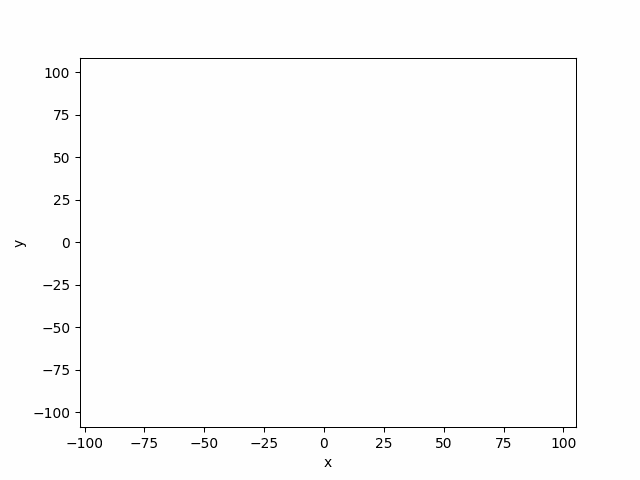

In [119]:
p = generate_uniform_points(-100, 100, 100)
vis, convex_hull = Convex_Hull_vis(p)
vis.show_gif()

In [117]:
def bin_r_tangent_vis(p, hull):
    vis = Visualizer()
    vis.add_point(hull)
    vis.add_point(p,color="red")


    n = len(hull)
    if n==1:
        return 0
    if n==2:
        if cmp(p, hull[0], hull[1]) <0:
            return 0
        else: return 1
    #analizujemy wierzhołi od [v0, v1, .., vn]  gdzie vn = v0
    l, r = 0, len(hull)
    l_vis, r_vis = vis.add_point(hull[0], color="green"), vis.add_point(hull[0], color="orange")
    # sprawdzamy czy v0 jest wierzchołkiem stycznym
    if orient(p, hull[0], hull[1]) >0 and orient(p, hull[0], hull[n - 1]) >=0:
        return 0
    while True:
        c = (l+r)//2
        c_vis = vis.add_point(hull[c], color="red")
        line = vis.add_line([p, hull[c]], color="red")
        # sprawdzamy, czy vc jest wierzchołkiem stycznym
        if orient(p, hull[c], hull[(c + 1) % n]) >0 and orient(p, hull[c], hull[(c - 1) % n]) >=0:
            return vis, c
        # vis.remove_figure(line)
        # sprawdzamy czy wektor vl v(l+1) jest skierowany "do góry" <=> vl należy do łańcucha rosnącego
        if isEdgeIncreasing(hull, l, n, p):
            # sprawdzamy czy wektor vc v(c+1) jest skierowany "do dołu" <=> vc należy do łańcucha malejącego
            if isEdgeDecreasing(c, hull, n, p):
                # wierzchołek styczny będzie w przedziale [l,c]
                r=c
                vis.remove_figure(c_vis)
                vis.remove_figure(r_vis)
                r_vis = vis.add_point(hull[r], color="orange")
            # w innym przypadku vl należy vc należy do łańcucha rosnącego
            else:
                if orient(p, hull[l], hull[c]) <0 or (isCollinearAndDecreasingP(c, hull, l, n, p) and d(p, hull[l]) < d(p, hull[(c) % n])) or (isCollinearAndApproachingP(c, hull, l, n, p) and d(p, hull[l]) > d(p, hull[(c) % n])):
                    # wierzchołek styczny będzie w przedziale [c,r]
                    l=c
                    vis.remove_figure(c_vis)
                    vis.remove_figure(l_vis)
                    l_vis = vis.add_point(hull[l], color="green")
                else:
                    # wierzchołek styczny będzie w przedziale [l,c]
                    r=c
                    vis.remove_figure(c_vis)
                    vis.remove_figure(r_vis)
                    r_vis = vis.add_point(hull[r], color="orange")

        else:
            if isEdgeIncreasing(hull, c, n, p):
                    l=c
                    vis.remove_figure(c_vis)
                    vis.remove_figure(l_vis)
                    l_vis = vis.add_point(hull[l], color="green")
            else:
                if( orient(p, hull[l], hull[c]) <0) or (isCollinearAndDecreasingP(c, hull, l, n, p) and d(p, hull[l]) < d(p, hull[(c) % n])) or (isCollinearAndApproachingP(c, hull, l, n, p) and d(p, hull[l]) > d(p, hull[(c) % n])):
                    r=c
                    vis.remove_figure(c_vis)
                    vis.remove_figure(r_vis)
                    r_vis = vis.add_point(hull[r], color="orange")
                else:
                    l=c
                    vis.remove_figure(c_vis)
                    vis.remove_figure(r_vis)
                    r_vis = vis.add_point(hull[r], color="orange")
        vis.remove_figure(line)


In [115]:
def generate_circle_points(O, R, n=100):
    """
    Funkcja generuje jednostajnie n punktów na okręgu o środku O i promieniu R
    :param O: krotka współrzędnych x, y określająca środek okręgu
    :param R: promień okręgu
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
    """
    result = [None for _ in range(n)]
    for i in range(n):
        t = np.random.uniform(0, 2 *np.pi)
        result[i] = (R*np.cos(t)+O[0], R*np.sin(t)+O[1])
    return result


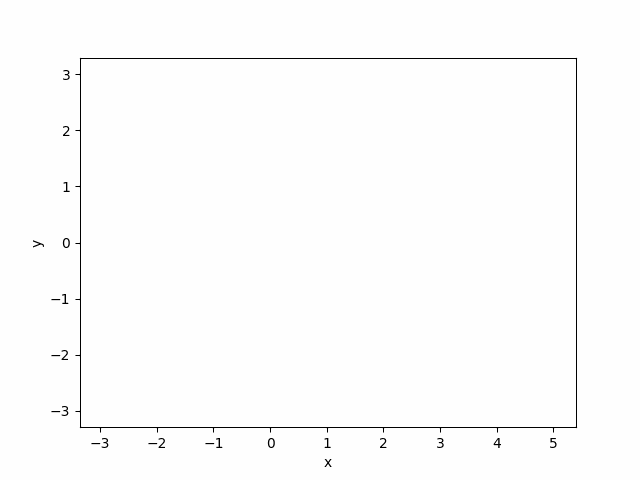

In [118]:
points = generate_circle_points((0,0),3,30)
points = Convex_Hull(points)
z = (5,1)
tans, c = bin_r_tangent_vis(z, points)
tans.show_gif(interval=1000)